### Import Packages

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Input, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras_tuner import HyperModel, Hyperband

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version: ", tf.__version__)
print("Number of GPUs available: ", len(tf.config.list_physical_devices('GPU')))

TensorFlow version:  2.19.0
Number of GPUs available:  1


### Data Preprocessing

In [3]:
cols = ['u_e','u_n']

# Load datasets
df_stn = pd.read_csv('Sikorsky_data.csv')
df_stn = df_stn.rename(columns={'WSPD':'u'})
df_stn['TmStamp'] = pd.to_datetime(df_stn['TmStamp'], format='mixed')
df_stn.set_index('TmStamp', inplace=True)

df_buoy = pd.read_csv('WLIS_data.csv')
df_buoy = df_buoy.rename(columns={'WSPD':'u'})
df_buoy['TmStamp'] = pd.to_datetime(df_buoy['TmStamp'], format='mixed')
df_buoy.set_index('TmStamp', inplace=True)

# Add east and north components
alpha = -13
df_stn['rad'] = np.pi/180 * ((alpha + 630 - df_stn['WDIR']) % 360)
df_stn['u_e'] = df_stn['u'] * np.cos(df_stn['rad'])
df_stn['u_n'] = df_stn['u'] * np.sin(df_stn['rad'])

df_buoy['rad'] = np.pi/180 * ((alpha + 630 - df_buoy['WDIR']) % 360)
df_buoy['u_e'] = df_buoy['u'] * np.cos(df_buoy['rad'])
df_buoy['u_n'] = df_buoy['u'] * np.sin(df_buoy['rad'])

# df_test: [2024-07-01 00:00:00 ~ 2025-06-30 23:00:00]
split = pd.to_datetime('2024-06-30 23:59:00')
df_stn_train = df_stn[df_stn.index < split]
df_stn_test = df_stn[df_stn.index > split]

df_buoy_train = df_buoy[df_buoy.index < split]
df_buoy_test = df_buoy[df_buoy.index > split]

# Train-Test split
X_train, y_train = df_stn_train[cols].values, df_buoy_train[cols].values
X_test, y_test = df_stn_test[cols].values, df_buoy_test[cols].values

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(114768, 2) (114768, 2)
(8760, 2) (8760, 2)


### Model Training

In [4]:
class DenseHyperModel(HyperModel):
    def build(self, hp):
        model = Sequential()
        
        # Input layer
        model.add(Input(shape=(X_train.shape[1],)))
        
        # Tunable layers and units
        num_layers = hp.Int('layers', min_value=1, max_value=4, step=1)
        for i in range(num_layers):
            model.add(Dense(
                units=hp.Choice(f'units_{i}', values=[16, 32, 64, 128, 256]),
                activation='leaky_relu'))
        
        # Output layer
        model.add(Dense(y_train.shape[1]))

        # Compile the model
        model.compile(
            optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')),
            loss='mse')
        
        return model

# Search space setup
tuner = Hyperband(
    DenseHyperModel(),
    objective='val_loss',
    max_epochs=100,
    factor=3,
    directory='hp_tuning',
    project_name='wind_MLP',
)

# Hyperparameter tuning
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
tuner.search(X_train, y_train, epochs=100, batch_size=64, validation_split=0.1, callbacks=[es])

Reloading Tuner from hp_tuning/wind_MLP/tuner0.json


In [5]:
# Best hyperparameters
best_hp = tuner.get_best_hyperparameters()[0]
print(best_hp.values)
print()

# Best model
best_model = tuner.hypermodel.build(best_hp)
best_model.compile(optimizer=Adam(learning_rate=best_hp.values['learning_rate']), loss='mse')
print(best_model.summary())

{'layers': 3, 'units_0': 16, 'learning_rate': 0.001958975633214816, 'units_1': 32, 'units_2': 256, 'units_3': 128, 'tuner/epochs': 100, 'tuner/initial_epoch': 34, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0231'}



I0000 00:00:1759546112.280586 2552975 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38483 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:e2:00.0, compute capability: 8.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,554 (37.32 KB)

 Trainable params: 9,554 (37.32 KB)

 Non-trainable params: 0 (0.00 B)

None


I0000 00:00:1759546117.812370 2553976 service.cc:152] XLA service 0x7f9ac8006380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759546117.812405 2553976 service.cc:160]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2025-10-03 22:48:37.832525: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1759546117.932048 2553976 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1759546119.358086 2553976 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


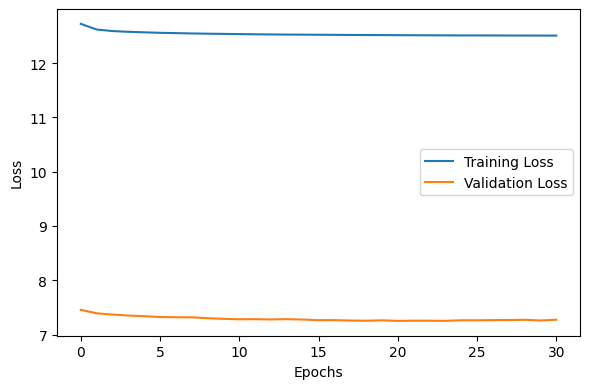

In [6]:
model_file = 'wind_MLP.keras'

# Train and save the model (architecture + weights)
history = best_model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.1, callbacks=[es], verbose=0)
best_model.save(model_file)

# Plot the training & validation loss over epochs
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Model Evaluation

In [7]:
# Load the saved model
model = load_model(model_file)

# Training error
y_pred1 = model.predict(X_train, verbose=0)
y_pred1_u = np.sqrt(y_pred1[:, 0]**2 + y_pred1[:, 1]**2)

mae_arr1 = mean_absolute_error(y_train, y_pred1, multioutput='raw_values')
mae_u1 = mean_absolute_error(df_buoy_train['u'], y_pred1_u)
print('Training MAE (u_e, u_n):', ', '.join([f'{mae:.3f}' for mae in mae_arr1]))
print(f'Training MAE (u): {mae_u1:.3f}')

rmse_arr1 = np.sqrt(mean_squared_error(y_train, y_pred1, multioutput='raw_values'))
rmse_u1 = np.sqrt(mean_squared_error(df_buoy_train['u'], y_pred1_u))
print('Training RMSE (u_e, u_n):', ', '.join([f'{rmse:.3f}' for rmse in rmse_arr1]))
print(f'Training RMSE (u): {rmse_u1:.3f}')

# Test error
y_pred2 = model.predict(X_test, verbose=0)
y_pred2_u = np.sqrt(y_pred2[:, 0]**2 + y_pred2[:, 1]**2)

mae_arr2 = mean_absolute_error(y_test, y_pred2, multioutput='raw_values')
mae_u2 = mean_absolute_error(df_buoy_test['u'], y_pred2_u)
print('Test MAE (u_e, u_n):', ', '.join([f'{mae:.3f}' for mae in mae_arr2]))
print(f'Test MAE (u): {mae_u2:.3f}')

rmse_arr2 = np.sqrt(mean_squared_error(y_test, y_pred2, multioutput='raw_values'))
rmse_u2 = np.sqrt(mean_squared_error(df_buoy_test['u'], y_pred2_u))
print('Test RMSE (u_e, u_n):', ', '.join([f'{rmse:.3f}' for rmse in rmse_arr2]))
print(f'Test RMSE (u): {rmse_u2:.3f}')

Training MAE (u_e, u_n): 2.681, 2.345
Training MAE (u): 2.493
Training RMSE (u_e, u_n): 3.736, 3.164
Training RMSE (u): 3.268
Test MAE (u_e, u_n): 2.192, 1.966
Test MAE (u): 2.335
Test RMSE (u_e, u_n): 2.789, 2.525
Test RMSE (u): 2.844
